## backproptexto.py


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Dense, GlobalAveragePooling1D, Dropout

# 1. Dataset ampliado con 4 clases
textos = [
    # 0: Muy Negativo (Estafa, enojo extremo, daño total)
    "Esto es una completa estafa no me llego nada y me cobraron",
    "Pesimo servicio un asco total no sirve nada",
    "Llego completamente roto y se niegan a devolver el dinero",
    "Horrible experiencia jamas volvere a comprar me robaron",

    # 1: Neutro / Dudoso / Informativo
    "El producto llego en tiempo promedio cumple apenas con lo basico",
    "Funciona segun las especificaciones tecnicas normales",
    "El paquete llego hoy empaquetado estandar",
    "Es regular ni muy bueno ni muy malo cumple funciones",

    # 2: Positivo
    "Buen producto llego a tiempo y funciona bien",
    "Satisfecho con la compra llego en buenas condiciones",
    "Me gusto bastante es util y comodo",
    "Todo correcto calidad aceptable por el precio",

    # 3: Muy Positivo / Excelente
    "Absolutamente increible la mejor compra que he realizado",
    "Excelente calidad servicio perfecto e insuperable me fascina",
    "Supero todas mis expectativas excelente producto y atencion impecable",
    "Maravilloso rendimiento diseno impecable lo recomiendo totalmente"
]

etiquetas = np.array([
    0, 0, 0, 0,
    1, 1, 1, 1,
    2, 2, 2, 2,
    3, 3, 3, 3
], dtype=np.int32)

nombres_sentimientos = ["Muy Negativo", "Neutro", "Positivo", "Muy Positivo"]

# 2. Vectorización y preprocesamiento
max_palabras = 500
max_longitud = 12

vectorizer = TextVectorization(
    max_tokens=max_palabras,
    output_sequence_length=max_longitud,
    standardize="lower_and_strip_punctuation"
)
vectorizer.adapt(textos)

# 3. Arquitectura mejorada (Embedding de mayor dimensión y regularización Dropout)
modelo_texto = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    Embedding(input_dim=max_palabras, output_dim=16),
    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')  # 4 clases de salida
])

modelo_texto.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_texto.fit(np.array(textos, dtype=object), etiquetas, epochs=120, verbose=0)

# 4. Pruebas con oraciones no vistas
nuevos_textos = np.array([
    "Pague y nunca enviaron nada son unos rateros",
    "El articulo llego dentro del plazo esperado sin novedades",
    "Me gusto mucho la compra bastante funcional",
    "Espectacular y fantastico totalmente satisfecho con la calidad"
], dtype=object)

predicciones = modelo_texto.predict(nuevos_textos)
for texto, pred in zip(nuevos_textos, predicciones):
    clase_idx = np.argmax(pred)
    confianza = pred[clase_idx] * 100
    print(f"Texto: '{texto}'\n -> Sentimiento: {nombres_sentimientos[clase_idx]} ({confianza:.2f}%)\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Texto: 'Pague y nunca enviaron nada son unos rateros'
 -> Sentimiento: Positivo (49.55%)

Texto: 'El articulo llego dentro del plazo esperado sin novedades'
 -> Sentimiento: Neutro (84.83%)

Texto: 'Me gusto mucho la compra bastante funcional'
 -> Sentimiento: Positivo (95.57%)

Texto: 'Espectacular y fantastico totalmente satisfecho con la calidad'
 -> Sentimiento: Positivo (84.63%)



## RedBackpropagationCIFAR

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import layers, datasets

class RedBackpropagationCIFAR:
    def __init__(self, input_shape=(32, 32, 3), num_classes=10):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.historia = None
        self.nombres_clases = [
            'avion', 'automovil', 'pajaro', 'gato', 'ciervo',
            'perro', 'rana', 'caballo', 'barco', 'camion'
        ]

    def construir_modelo(self, capas_ocultas=[512, 256, 128], dropout_rate=0.2):
        """Diseña la arquitectura MLP con regularización."""
        model_layers = [layers.Flatten(input_shape=self.input_shape)]
        for neuronas in capas_ocultas:
            model_layers.append(layers.Dense(neuronas, activation='relu'))
            if dropout_rate > 0:
                model_layers.append(layers.Dropout(dropout_rate))

        model_layers.append(layers.Dense(self.num_classes, activation='softmax'))
        self.model = keras.Sequential(model_layers)

        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def resumen(self):
        """Muestra la arquitectura y número de parámetros."""
        if self.model is None:
            raise ValueError("El modelo no ha sido construido ni cargado.")
        self.model.summary()

    def entrenar(self, X_train, y_train, X_val, y_val, epochs=15, batch_size=64):
        """Ejecuta el ciclo de entrenamiento y almacena el historial."""
        if self.model is None:
            self.construir_modelo()

        self.historia = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            verbose=1
        )
        return self.historia

    def graficar_rendimiento(self):
        """Genera curvas de Loss y Accuracy para Train y Validación."""
        if self.historia is None:
            print("No hay historial disponible (el modelo se cargó o no se ha entrenado).")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Precisión
        ax1.plot(self.historia.history['accuracy'], label='Entrenamiento', color='#1f77b4', lw=2)
        ax1.plot(self.historia.history['val_accuracy'], label='Validación', color='#ff7f0e', lw=2)
        ax1.set_title('Exactitud por Época')
        ax1.set_xlabel('Época')
        ax1.set_ylabel('Accuracy')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.legend()

        # Pérdida
        ax2.plot(self.historia.history['loss'], label='Entrenamiento', color='#1f77b4', lw=2)
        ax2.plot(self.historia.history['val_loss'], label='Validación', color='#ff7f0e', lw=2)
        ax2.set_title('Pérdida por Época')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('Loss')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def guardar_modelo(self, ruta_archivo="modelo_cifar10_backprop.keras"):
        """Almacena el modelo en formato nativo Keras."""
        if self.model is None:
            raise ValueError("No hay modelo para guardar.")
        self.model.save(ruta_archivo)
        print(f"Modelo guardado exitosamente en: {ruta_archivo}")

    def cargar_modelo(self, ruta_archivo="modelo_cifar10_backprop.keras"):
        """Carga los pesos y arquitectura desde disco."""
        if not os.path.exists(ruta_archivo):
            raise FileNotFoundError(f"El archivo {ruta_archivo} no existe.")
        self.model = keras.models.load_model(ruta_archivo)
        print(f"Modelo cargado exitosamente desde: {ruta_archivo}")

    def predecir_imagen_externa(self, ruta_imagen):
        """Procesa una imagen externa arbitraria (JPG/PNG) y la clasifica."""
        if not os.path.exists(ruta_imagen):
            raise FileNotFoundError(f"Imagen no encontrada en: {ruta_imagen}")

        img_pil = Image.open(ruta_imagen).convert('RGB')
        img_redim = img_pil.resize((self.input_shape[0], self.input_shape[1]))
        img_tensor = np.array(img_redim).astype("float32") / 255.0
        img_batch = np.expand_dims(img_tensor, axis=0)

        pred = self.model.predict(img_batch, verbose=0)
        clase_idx = np.argmax(pred[0])
        confianza = pred[0][clase_idx] * 100

        plt.figure(figsize=(4, 4))
        plt.imshow(img_pil)
        plt.title(f"Pred: {self.nombres_clases[clase_idx].upper()} ({confianza:.2f}%)")
        plt.axis('off')
        plt.show()

        return self.nombres_clases[clase_idx], confianza

## Prueba de CIFAR


--- Cargando dataset CIFAR-10 ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1504s 9us/step

--- Resumen de la Red Neuronal ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


--- Iniciando ciclo de entrenamiento ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.2443 - loss: 2.0366 - val_accuracy: 0.3235 - val_loss: 1.8465
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3014 - loss: 1.9000 - val_accuracy: 0.3496 - val_loss: 1.8103
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.3224 - loss: 1.8484 - val_accuracy: 0.3706 - val_loss: 1.7701
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.3326 - loss: 1.8187 - val_accuracy: 0.3902 - val_loss: 1.7162
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.3445 - loss: 1.7971 - val_accuracy: 0.3833 - val_loss: 1.7099
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.3499 - loss: 1.7838 - val_accuracy: 0.3964 - val_loss: 1.6842
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.3548 - loss: 1.7656 - val_accuracy: 0.3989 - val_loss: 1.6744
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms

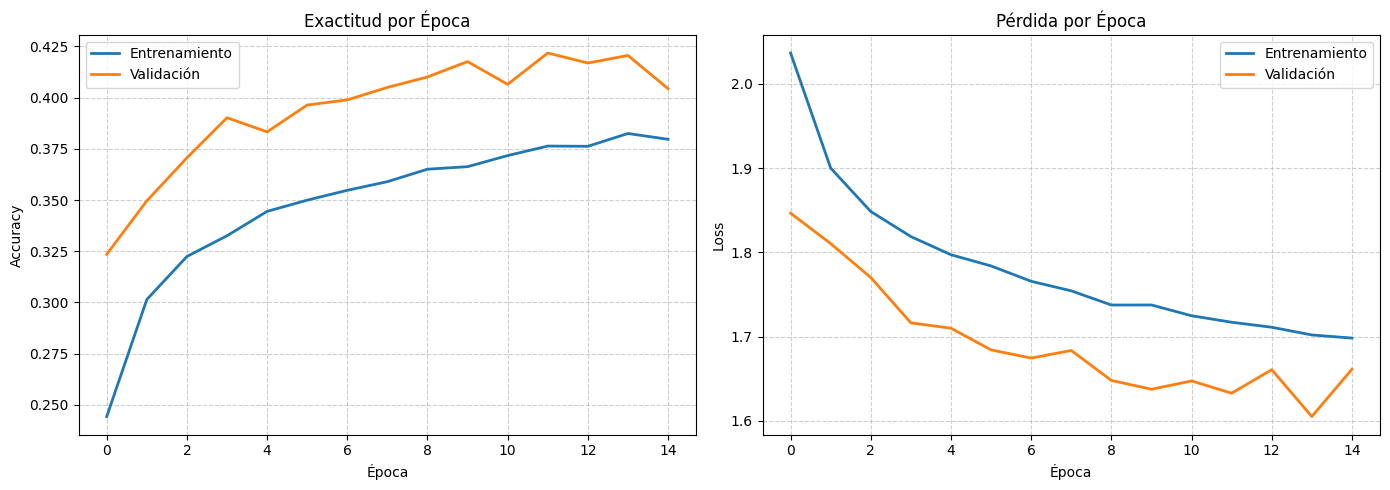

Modelo guardado exitosamente en: mi_red_cifar10.keras


In [6]:
import numpy as np
from tensorflow.keras import datasets

# 1. Cargar y preparar CIFAR-10
print("--- Cargando dataset CIFAR-10 ---")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalización de los canales RGB al rango [0.0, 1.0]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 2. Instanciar la red
red = RedBackpropagationCIFAR(input_shape=(32, 32, 3), num_classes=10)

# 3. Construir la arquitectura (puedes ajustar capas y dropout)
red.construir_modelo(capas_ocultas=[512, 256, 128], dropout_rate=0.25)

# 4. Mostrar el resumen del modelo en consola
print("\n--- Resumen de la Red Neuronal ---")
red.resumen()

# 5. Entrenar la red
print("\n--- Iniciando ciclo de entrenamiento ---")
red.entrenar(
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    epochs=15,
    batch_size=64
)

# 6. Desplegar los gráficos de Loss y Accuracy (Entrenamiento vs Validación)
print("\n--- Generando curvas de aprendizaje ---")
red.graficar_rendimiento()

# 7. Guardar el modelo entrenado en disco
red.guardar_modelo("mi_red_cifar10.keras")